# Quantitative Portfolio Optimization

## Modern Portfolio Theory Using Real Market Data

This notebook develops a complete quantitative portfolio optimization analysis using historical market prices and Modern Portfolio Theory.

The analysis includes:

- Historical adjusted market prices
- Daily and annualized returns
- Volatility, covariance, and correlation
- Random portfolio simulation
- Minimum-variance portfolio
- Maximum-Sharpe portfolio
- Professional financial visualizations

The project is educational and analytical. Its results do not constitute financial advice.

---

**Author:** Alex Carrillo  
**Technology:** Python  
**Field:** Quantitative Finance and Portfolio Management

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Allow imports when the notebook starts from the project root
# or directly from the notebooks directory.
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import (
    calculate_simple_returns,
    download_adjusted_prices,
)
from src.optimization import (
    maximum_sharpe_portfolio,
    minimum_variance_portfolio,
)
from src.portfolio_metrics import (
    annualized_covariance_matrix,
    annualized_expected_returns,
)
from src.simulation import simulate_random_portfolios

sns.set_theme(style="whitegrid", context="notebook")

print(f"Python executable: {sys.executable}")
print(f"Project root: {project_root}")
print("Imports completed successfully.")

Python executable: c:\Users\Admin\Documents\Utech\Proyectos\portfolio-optimization-engine\.venv\Scripts\python.exe
Project root: c:\Users\Admin\Documents\Utech\Proyectos\portfolio-optimization-engine
Imports completed successfully.


## 1. Portfolio Configuration

The analysis uses five exchange-traded funds representing different market exposures:

| Ticker | Market exposure |
|---|---|
| SPY | Large-cap U.S. equities |
| QQQ | Nasdaq and technology-oriented equities |
| IWM | U.S. small-cap equities |
| TLT | Long-term U.S. Treasury bonds |
| GLD | Gold |

Combining assets with different risk and return characteristics creates opportunities for diversification.

tickers = ["SPY", "QQQ", "IWM", "TLT", "GLD"]

start_date = "2021-01-01"
end_date = "2026-01-01"

periods_per_year = 252
risk_free_rate = 0.03
number_of_simulations = 100_000
random_seed = 42

print(f"Assets: {', '.join(tickers)}")
print(f"Historical period: {start_date} to {end_date}")
print(f"Risk-free rate: {risk_free_rate:.2%}")
print(f"Random portfolios: {number_of_simulations:,}")

## 2. Historical Market Data

Adjusted closing prices are downloaded from Yahoo Finance through the `yfinance` library.

Adjusted prices account for relevant corporate actions and allow the historical performance of different assets to be compared consistently.

prices = download_adjusted_prices(
    tickers=tickers,
    start_date=start_date,
    end_date=end_date,
)

returns = calculate_simple_returns(prices)

print(
    f"Available period: {prices.index.min().date()} "
    f"to {prices.index.max().date()}"
)
print(f"Price observations: {len(prices):,}")
print(f"Return observations: {len(returns):,}")

prices.tail()

## 3. Normalized Historical Performance

To compare assets with different market prices, each series is normalized to an initial value of 100.

This answers the following question:

> What would have happened to an initial investment of $100 in each asset?

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import (
    calculate_simple_returns,
    download_adjusted_prices,
)
from src.optimization import (
    maximum_sharpe_portfolio,
    minimum_variance_portfolio,
)
from src.portfolio_metrics import (
    annualized_covariance_matrix,
    annualized_expected_returns,
)
from src.simulation import simulate_random_portfolios

sns.set_theme(style="whitegrid", context="notebook")

tickers = ["SPY", "QQQ", "IWM", "TLT", "GLD"]
start_date = "2021-01-01"
end_date = "2026-01-01"
periods_per_year = 252
risk_free_rate = 0.03
number_of_simulations = 100_000
random_seed = 42

prices = download_adjusted_prices(
    tickers=tickers,
    start_date=start_date,
    end_date=end_date,
)

returns = calculate_simple_returns(prices)

print(f"Python executable: {sys.executable}")
print(f"Price observations: {len(prices):,}")
print(f"Return observations: {len(returns):,}")
print("Data loaded successfully.")

prices.tail()

Python executable: c:\Users\Admin\Documents\Utech\Proyectos\portfolio-optimization-engine\.venv\Scripts\python.exe
Price observations: 1,255
Return observations: 1,254
Data loaded successfully.


Ticker,SPY,QQQ,IWM,TLT,GLD
Date,,,,,
2025-12-24,686.730530,622.460266,251.662796,85.732704,411.929993
2025-12-26,686.660889,622.420288,250.378143,85.450279,416.739990
2025-12-29,684.213867,619.407410,248.844528,85.771667,398.600006
2025-12-30,683.378357,617.970764,247.002182,85.567139,398.890015
2025-12-31,678.315247,612.862854,245.139938,84.885406,396.309998


## 6. Portfolio Optimization

For a portfolio with asset-weight vector \(w\), expected returns \(\mu\), and covariance matrix \(\Sigma\):

### Expected portfolio return

\[
E(R_p)=w^T\mu
\]

### Portfolio volatility

\[
\sigma_p=\sqrt{w^T\Sigma w}
\]

### Sharpe ratio

\[
S_p=\frac{E(R_p)-r_f}{\sigma_p}
\]

Two portfolios are calculated:

1. **Minimum-variance portfolio:** minimizes total volatility.
2. **Maximum-Sharpe portfolio:** maximizes risk-adjusted return.

The optimization is long-only, and all weights must sum to 100%.

minimum_variance = minimum_variance_portfolio(
    expected_returns=expected_returns,
    covariance_matrix=covariance_matrix,
    risk_free_rate=risk_free_rate,
)

maximum_sharpe = maximum_sharpe_portfolio(
    expected_returns=expected_returns,
    covariance_matrix=covariance_matrix,
    risk_free_rate=risk_free_rate,
)

print("Portfolio optimization completed successfully.")

In [3]:
# Calculate annualized market inputs.
expected_returns = annualized_expected_returns(
    returns.to_numpy(),
    periods_per_year=periods_per_year,
)

covariance_matrix = annualized_covariance_matrix(
    returns.to_numpy(),
    periods_per_year=periods_per_year,
)

# Calculate both optimized portfolios.
minimum_variance = minimum_variance_portfolio(
    expected_returns=expected_returns,
    covariance_matrix=covariance_matrix,
    risk_free_rate=risk_free_rate,
)

maximum_sharpe = maximum_sharpe_portfolio(
    expected_returns=expected_returns,
    covariance_matrix=covariance_matrix,
    risk_free_rate=risk_free_rate,
)

# Create the portfolio weight comparison.
portfolio_weights = pd.DataFrame(
    {
        "Minimum variance": minimum_variance.weights,
        "Maximum Sharpe": maximum_sharpe.weights,
    },
    index=tickers,
)

# Create the portfolio metric comparison.
portfolio_summary = pd.DataFrame(
    {
        "Expected return": [
            minimum_variance.metrics.expected_return,
            maximum_sharpe.metrics.expected_return,
        ],
        "Volatility": [
            minimum_variance.metrics.volatility,
            maximum_sharpe.metrics.volatility,
        ],
        "Sharpe ratio": [
            minimum_variance.metrics.sharpe_ratio,
            maximum_sharpe.metrics.sharpe_ratio,
        ],
    },
    index=[
        "Minimum variance",
        "Maximum Sharpe",
    ],
)

print("Portfolio optimization completed successfully.")

display(
    portfolio_weights.style.format("{:.2%}")
)

display(
    portfolio_summary.style.format(
        {
            "Expected return": "{:.2%}",
            "Volatility": "{:.2%}",
            "Sharpe ratio": "{:.4f}",
        }
    )
)

Portfolio optimization completed successfully.


,Minimum variance,Maximum Sharpe
SPY,32.83%,40.83%
QQQ,0.00%,0.00%
IWM,0.00%,0.00%
TLT,33.75%,0.00%
GLD,33.42%,59.17%


,Expected return,Volatility,Sharpe ratio
Minimum variance,8.10%,10.63%,0.4793
Maximum Sharpe,16.16%,12.26%,1.0733


## 7. Random Portfolio Simulation

One hundred thousand long-only portfolios are generated using random combinations of asset weights.

Each simulated portfolio produces:

- Expected annual return
- Annualized volatility
- Sharpe ratio

The resulting cloud represents the investment opportunity set. Its upper boundary approximates the efficient frontier.

simulation = simulate_random_portfolios(
    expected_returns=expected_returns,
    covariance_matrix=covariance_matrix,
    simulations=number_of_simulations,
    risk_free_rate=risk_free_rate,
    seed=random_seed,
)

print(
    f"{len(simulation.weights):,} portfolios "
    "simulated successfully."
)

In [4]:
simulation = simulate_random_portfolios(
    expected_returns=expected_returns,
    covariance_matrix=covariance_matrix,
    simulations=number_of_simulations,
    risk_free_rate=risk_free_rate,
    seed=random_seed,
)

print(
    f"{len(simulation.weights):,} portfolios "
    "simulated successfully."
)

100,000 portfolios simulated successfully.


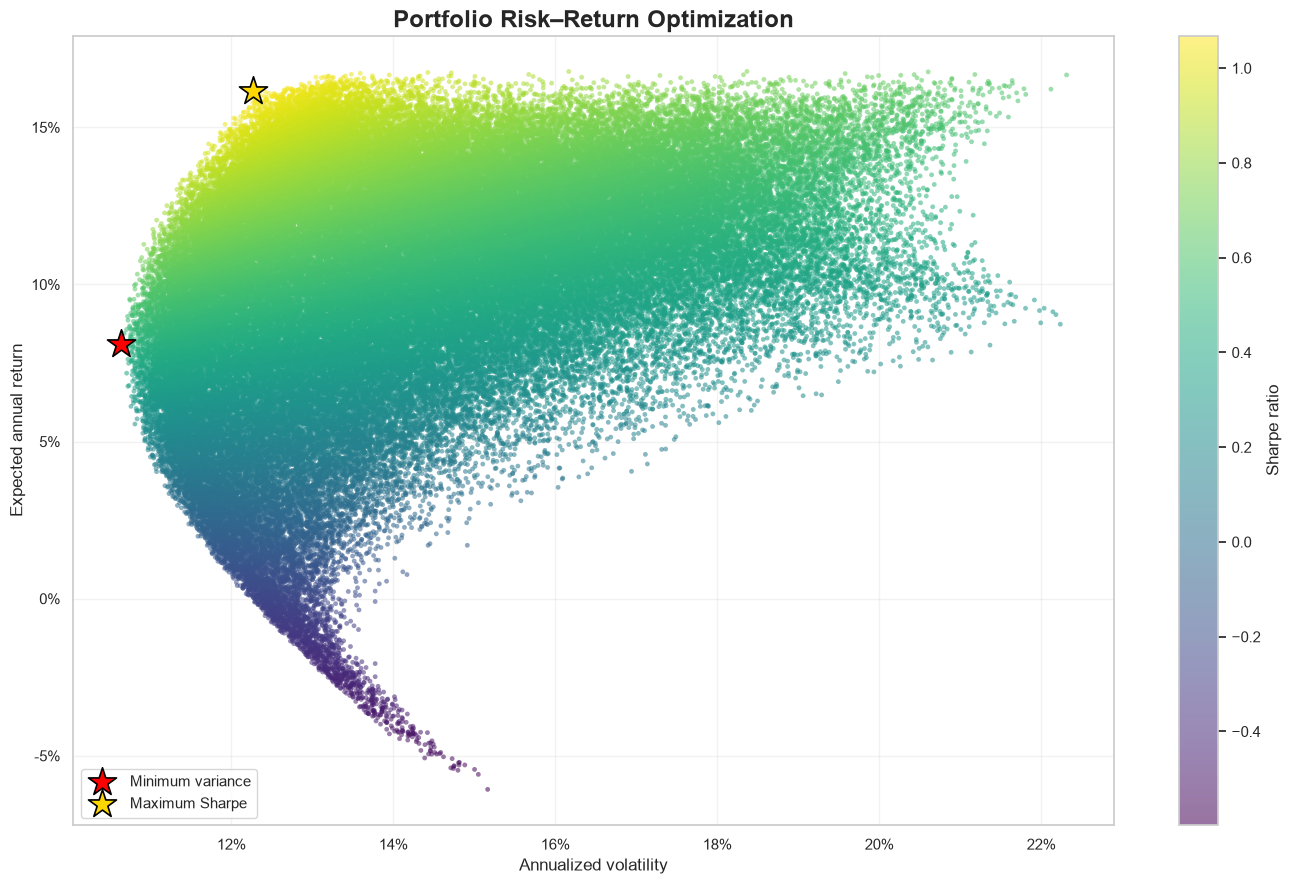

In [5]:
figure, axis = plt.subplots(figsize=(14, 9))

scatter = axis.scatter(
    simulation.volatilities,
    simulation.expected_returns,
    c=simulation.sharpe_ratios,
    cmap="viridis",
    s=12,
    alpha=0.55,
    edgecolors="none",
)

axis.scatter(
    minimum_variance.metrics.volatility,
    minimum_variance.metrics.expected_return,
    marker="*",
    s=450,
    color="red",
    edgecolor="black",
    linewidth=1.2,
    label="Minimum variance",
    zorder=5,
)

axis.scatter(
    maximum_sharpe.metrics.volatility,
    maximum_sharpe.metrics.expected_return,
    marker="*",
    s=450,
    color="gold",
    edgecolor="black",
    linewidth=1.2,
    label="Maximum Sharpe",
    zorder=5,
)

color_bar = figure.colorbar(scatter, ax=axis)
color_bar.set_label("Sharpe ratio")

axis.set_title(
    "Portfolio Risk–Return Optimization",
    fontsize=17,
    fontweight="bold",
)
axis.set_xlabel("Annualized volatility")
axis.set_ylabel("Expected annual return")

axis.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value:.0%}"
    )
)
axis.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position: f"{value:.0%}"
    )
)

axis.legend()
axis.grid(alpha=0.25)

figure.tight_layout()
plt.show()

## 8. Interpretation of the Optimized Portfolios

The minimum-variance portfolio prioritizes capital stability by selecting the combination of assets with the lowest estimated volatility.

The maximum-Sharpe portfolio accepts additional risk when that risk is compensated by a sufficiently higher expected return.

Neither portfolio is universally superior:

- A conservative investor may prefer minimum variance.
- An investor focused on risk-adjusted performance may prefer maximum Sharpe.
- Historical estimates do not guarantee future results.

In [7]:
def print_portfolio_report(
    title,
    optimization_result,
):
    print(f"\n{title}")

    for ticker, weight in zip(
        tickers,
        optimization_result.weights,
        strict=True,
    ):
        print(f"{ticker}: {weight:.2%}")

    print(
        "Expected annual return: "
        f"{optimization_result.metrics.expected_return:.2%}"
    )
    print(
        "Annual volatility: "
        f"{optimization_result.metrics.volatility:.2%}"
    )
    print(
        "Sharpe ratio: "
        f"{optimization_result.metrics.sharpe_ratio:.4f}"
    )


print_portfolio_report(
    "Minimum-variance portfolio",
    minimum_variance,
)

print_portfolio_report(
    "Maximum-Sharpe portfolio",
    maximum_sharpe,
)


Minimum-variance portfolio
SPY: 32.83%
QQQ: 0.00%
IWM: 0.00%
TLT: 33.75%
GLD: 33.42%
Expected annual return: 8.10%
Annual volatility: 10.63%
Sharpe ratio: 0.4793

Maximum-Sharpe portfolio
SPY: 40.83%
QQQ: 0.00%
IWM: 0.00%
TLT: 0.00%
GLD: 59.17%
Expected annual return: 16.16%
Annual volatility: 12.26%
Sharpe ratio: 1.0733


## 9. Conclusions

This analysis demonstrates how Modern Portfolio Theory transforms historical market information into systematic portfolio decisions.

The project successfully:

1. Downloaded and validated real adjusted market prices.
2. Calculated daily and annualized returns.
3. Measured volatility, covariance, and correlation.
4. Simulated 100,000 long-only portfolios.
5. Identified the minimum-variance portfolio.
6. Identified the maximum-Sharpe portfolio.
7. Compared exact optimization with random simulation.
8. Visualized the risk–return opportunity set.

The results depend on historical data, the selected period, and the assumptions of the model. They should be interpreted as an educational quantitative analysis and not as financial advice.

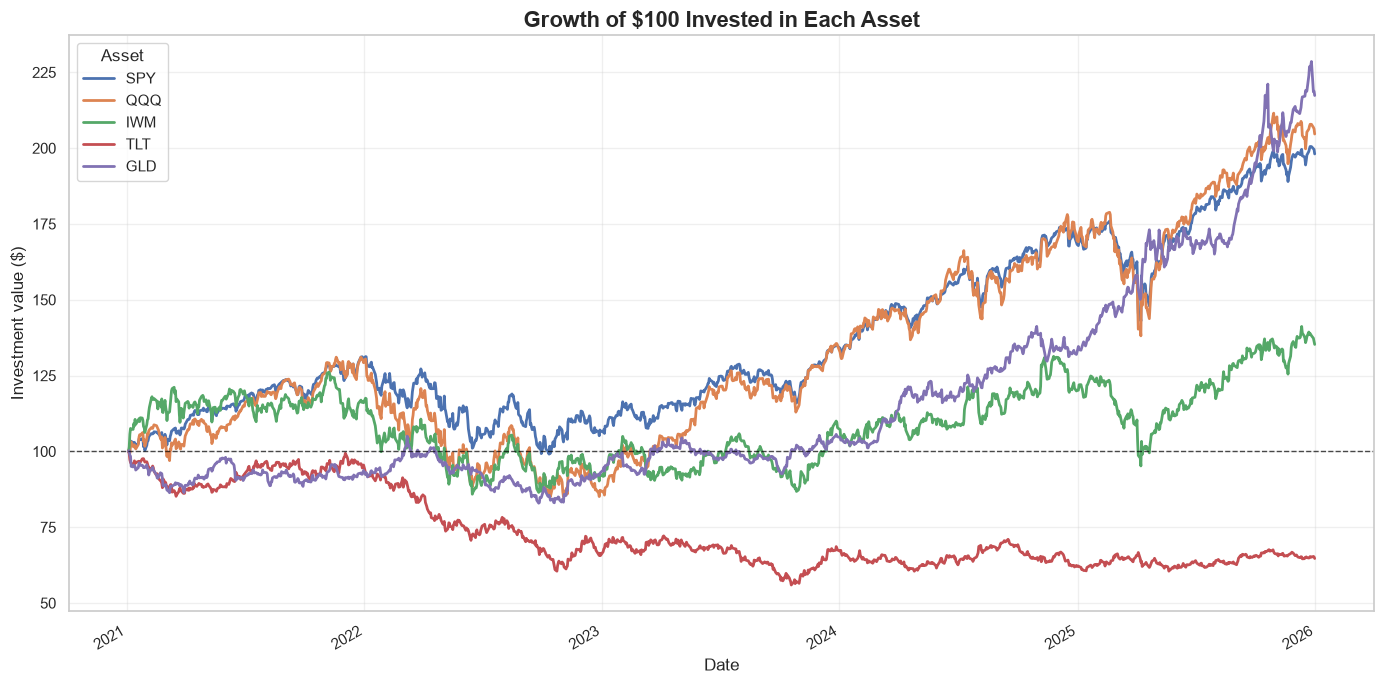

In [8]:
normalized_prices = prices.divide(
    prices.iloc[0]
) * 100.0

figure, axis = plt.subplots(figsize=(14, 7))

normalized_prices.plot(
    ax=axis,
    linewidth=2.0,
)

axis.set_title(
    "Growth of $100 Invested in Each Asset",
    fontsize=16,
    fontweight="bold",
)
axis.set_xlabel("Date")
axis.set_ylabel("Investment value ($)")
axis.axhline(
    100.0,
    color="black",
    linestyle="--",
    linewidth=1.0,
    alpha=0.7,
)
axis.legend(title="Asset")
axis.grid(alpha=0.30)

figure.tight_layout()
plt.show()

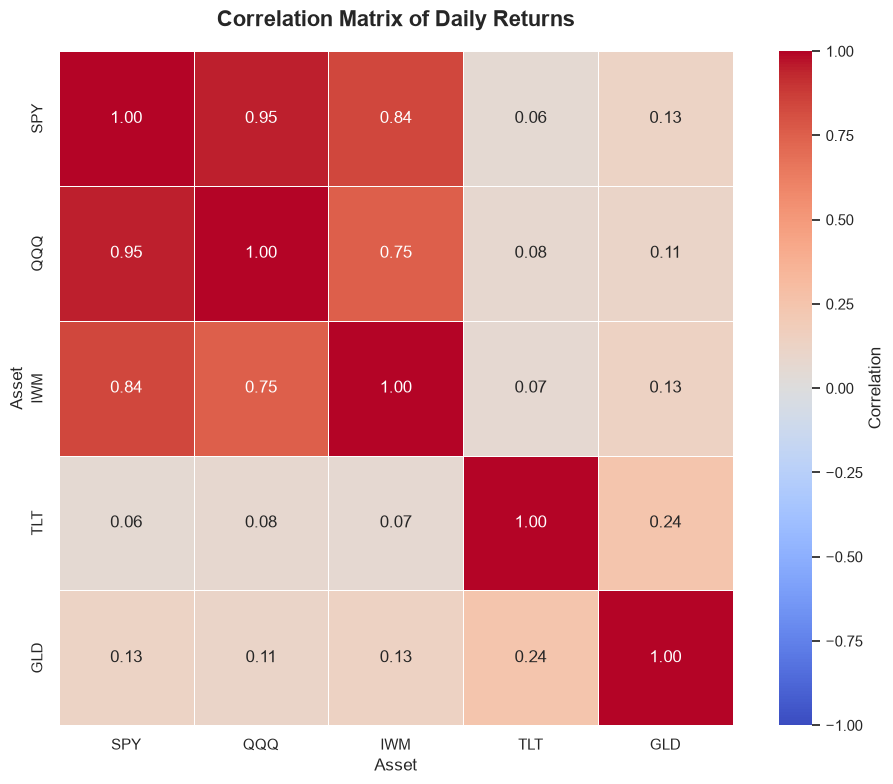

In [9]:
correlation_matrix = returns.corr()

figure, axis = plt.subplots(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0.0,
    vmin=-1.0,
    vmax=1.0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"},
    ax=axis,
)

axis.set_title(
    "Correlation Matrix of Daily Returns",
    fontsize=16,
    fontweight="bold",
    pad=18,
)
axis.set_xlabel("Asset")
axis.set_ylabel("Asset")

figure.tight_layout()
plt.show()